# Titanic Survival Prediction Project - Machine Learning

### Goal: Predict passenger survival using ML algorithms
### Type of Problem: Classification

## Problem Statement: 
The objective of this project is to build a Machine Learning model that predicts whether a passenger survived the Titanic disaster based on features like age, gender, ticket class, etc. 

## Dataset Description
Dataset: Titanic Dataset (Kaggle)

### Features:
- PassengerId
- Pclass (Ticket class)
- Name
- Sex
- Age
- SibSp (Sibling/Spouses aboard)
- Parch (Parents/Children aboard)
- Ticket
- Fare
- Cabin
- Embarked

### Target Feature:
- Survived (0 = No, 1 = Yes)

## Importing the libraries

In [5]:
# For data manipulation
import pandas as pd
import numpy as np

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [7]:
df = pd.read_csv("C:\\Users\\hbhan\\OneDrive\\Himanshu_Bhandari\\Projects for portfolio\\Titanic_Dataset.csv")

# Printing the first 5 rows of the dataset
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


## Exploratory Data Analysis (EDA)
In this section we will understand the structure of the dataset, check data types, and identify missing values.

In [9]:
print(df.info())
print("\n")
print(df.describe()) # Statistical summary about the dataset.
print("\n")
print(df.isnull().sum()) # Checking if there is any missing values in the dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486

## In this step, we handle the missing values and remove irrelevant features/columns that do not contribute to model performance. 

### Handling Missing Values and Dropping Irrelevant Columns

In [12]:
# Fill missing values in the Age column with median 
df["Age"].fillna(df["Age"].median(), inplace=True)

# Fill missing values in the Embarked column with mode
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Drop irrelevant columns
df.drop(columns=["PassengerId","Cabin","Name","Ticket"], axis = 1, inplace=True)

In [13]:
# Verifying the missing values again
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## Feature Engineering
Creating new features to improve model performance.

In [15]:
df["FamilySize"] = df["SibSp"] + df["Parch"]

We have created this feature because very small (alone traveller) or very large families may have different possibilites of survival, making it a useful feature for the algorithm.

### Applying Encoding Techniques

In [18]:
from sklearn.preprocessing import LabelEncoder

# Label encoding for sex (as it has binary values i.e. male and female)
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [19]:
# One-Hot Encoding for Embarked
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [20]:
# Checking the output for the data
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,1,False,True
1,1,1,0,38.0,1,0,71.2833,1,False,False
2,1,3,0,26.0,0,0,7.9250,0,False,True
3,1,1,0,35.0,1,0,53.1000,1,False,True
4,0,3,1,35.0,0,0,8.0500,0,False,True


## Defining Features and Target Feature
Separating the independent features and the target feature.

In [22]:
# Define X and y
X = df.drop("Survived", axis = 1)
y = df["Survived"]

In [23]:
# Convert boolean columns to integer (0/1)
bool_columns = X.select_dtypes(include="bool").columns
X[bool_columns] = X[bool_columns].astype(int)

## Feature Scaling 
We will scale all the numerical features so that all independent features are on a similar scale.
This is important for features like Logistic Regression and KNN.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
X.dtypes

Pclass          int64
Sex             int32
Age           float64
SibSp           int64
Parch           int64
Fare          float64
FamilySize      int64
Embarked_Q      int32
Embarked_S      int32
dtype: object

## Train - Test Split
Splitting the dataset into training and test sets to evaluate the model performance on unseen data.

In [28]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X_scaled,y, test_size=0.2, random_state=42)

## Model Building 
Training multiple machine learning models to compare their performance:
- Logistic Regression
- Decision Tree
- Random Forest

In [30]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

# Random Forest 
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train,y_train)

RandomForestClassifier()

## Model Evaluation
Evaluating the model performance based on accuracy score.

In [32]:
from sklearn.metrics import accuracy_score

models = [lr,dt,rf]
names = ["Logistic Regression","Decision Tree","Random Forest"]

for model, name in zip(models,names):
    y_pred = model.predict(X_test)
    print(name,"Accuracy Score:", accuracy_score(y_test,y_pred))

Logistic Regression Accuracy Score: 0.8100558659217877
Decision Tree Accuracy Score: 0.776536312849162
Random Forest Accuracy Score: 0.8100558659217877


## Confusion Matrix 
Understanding model performance in terms of true positives, false positives, true negatives, false negatives.


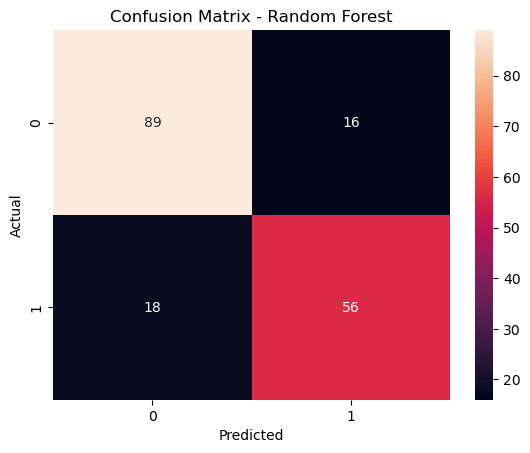

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

## Conclusion

- Random Forest achieved the highest accuracy of 83%, outperforming Logistic Regression and Decision Tree.
- The confusion matrix shows that the model performs well in predicting non-survivors (TN = 94).
- However, it misses some actual survivors (FN = 19), indicating scope for improvement in recall.
- Precision is high (~83%), meaning predictions of survival are reliable.
- Recall is moderate (~74%), suggesting the model does not capture all actual survivors.

Overall, Random Forest is selected as the final model due to its strong performance and balanced predictions.

In [36]:
import pickle

# Save model
pickle.dump(rf, open("Titanic_Model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [37]:
print(X.columns)

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')
